# EDA on 10k Slice of Auth Data

We're going to start our EDA by taking a look at the data and performing some sanity checks to better understand our data.

### Lets start by loading our data:

In [3]:
import gzip
import pandas as pd

AUTH_FILE = "../data/auth.txt.gz"

# Adjust column names to match LANL dataset
COLS = [
    "RecordID", "User", "AccountName", "SourceComputer", 
    "TargetComputer", "AuthPackage", "LogonType", "LogonAction", "Success"
]

def load_auth_sample(nrows=None):
    with gzip.open(AUTH_FILE, "rt") as f:
        df = pd.read_csv(f, sep=",", names=COLS, nrows=nrows, header=None)
    return df

# Load first 10,000 rows
df = load_auth_sample(nrows=10000)

print("Columns:", df.columns.tolist())
print("Head:\n", df.head())

# Basic stats
print("\nBasic stats:")
print("Number of rows:", len(df))
print("Unique users:", df['User'].nunique())
print("Unique computers:", df['TargetComputer'].nunique())
print("Success vs failure counts:\n", df['Success'].value_counts())


Columns: ['RecordID', 'User', 'AccountName', 'SourceComputer', 'TargetComputer', 'AuthPackage', 'LogonType', 'LogonAction', 'Success']
Head:
    RecordID                  User           AccountName SourceComputer  \
0         1  ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586          C1250   
1         1  ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586           C586   
2         1            C101$@DOM1            C101$@DOM1           C988   
3         1           C1020$@DOM1          SYSTEM@C1020          C1020   
4         1           C1021$@DOM1           C1021$@DOM1          C1021   

  TargetComputer AuthPackage LogonType LogonAction  Success  
0           C586        NTLM   Network       LogOn  Success  
1           C586           ?   Network      LogOff  Success  
2           C988           ?   Network      LogOff  Success  
3          C1020   Negotiate   Service       LogOn  Success  
4           C625    Kerberos   Network       LogOn  Success  

Basic stats:
Number of rows: 10000
Uniqu

### Next, lets do some intro EDA:


--- Sanity Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   RecordID        10000 non-null  int64 
 1   User            10000 non-null  object
 2   AccountName     10000 non-null  object
 3   SourceComputer  10000 non-null  object
 4   TargetComputer  10000 non-null  object
 5   AuthPackage     10000 non-null  object
 6   LogonType       10000 non-null  object
 7   LogonAction     10000 non-null  object
 8   Success         10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.3+ KB
None

Missing values per column:
 RecordID          0
User              0
AccountName       0
SourceComputer    0
TargetComputer    0
AuthPackage       0
LogonType         0
LogonAction       0
Success           0
dtype: int64

--- Basic Behavioral Stats ---
Unique users: 2142
Unique computers: 1709

Success vs Failure counts:
 Succe

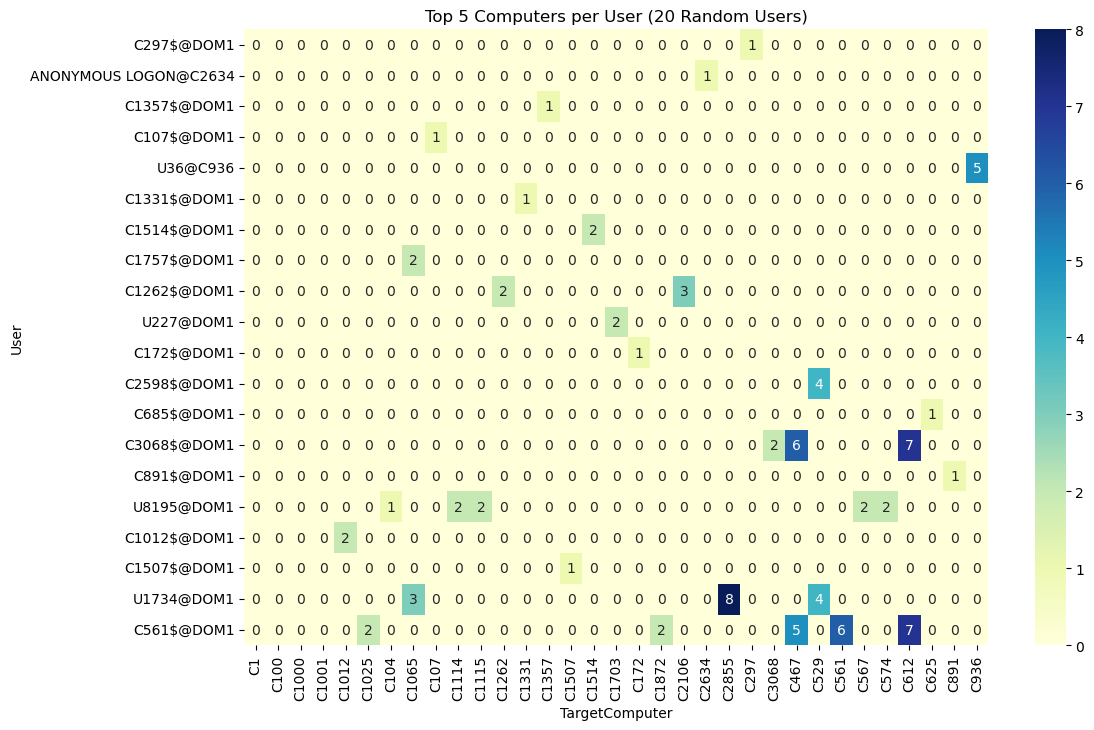

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Sanity checks ---
print("\n--- Sanity Check ---")
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())

# --- Basic behavioral stats ---
print("\n--- Basic Behavioral Stats ---")
print("Unique users:", df['User'].nunique())
print("Unique computers:", df['TargetComputer'].nunique())
print("\nSuccess vs Failure counts:\n", df['Success'].value_counts())
print("\nTop 5 AuthPackages:\n", df['AuthPackage'].value_counts().head())
print("\nTop 5 LogonTypes:\n", df['LogonType'].value_counts().head())

# --- User-computer interaction matrix ---
user_computer_counts = df.groupby(['User', 'TargetComputer']).size().unstack(fill_value=0)

# Now you can look at top users
top_users = df.groupby('User').size().sort_values(ascending=False).head(10).index
print("Top users (rows) in matrix snippet:")
print(user_computer_counts.loc[top_users].head())
# --- 4. Failed logins per user ---
fail_counts = df[df['Success'] == 'Fail']['User'].value_counts()
print("\nTop users by failure count:")
print(fail_counts.head(10))

# --- Heatmap of user-computer logins ---
user_computer_counts = df.groupby(['User', 'TargetComputer']).size().unstack(fill_value=0)

# Sample 20 random users
sample_users = df['User'].drop_duplicates().sample(20, random_state=42)
sample_uc_matrix = user_computer_counts.loc[sample_users]

top_n = 5
sample_uc_top = sample_uc_matrix.apply(lambda row: row.nlargest(top_n), axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(sample_uc_top.fillna(0).astype(int), cmap="YlGnBu", annot=True, fmt="d")
plt.xlabel("TargetComputer")
plt.ylabel("User")
plt.title(f"Top {top_n} Computers per User (20 Random Users)")
plt.show()


Okay, so now we know the data loaded correctly. We also can see that there are no missing values! Some key statistics - we have ~2100 unique users, as well as ~1700 unique computers. That gives us about .8 computers connected per user. 


We also see that of the 10k sample, only 96 attempts were failures. Thats an overall failure rate of under 1%! 


The most common AuthPackages are unknown, but of the known packages, the most common are Kerberos and Negotiate, which is expected as those are the default way Windows handles AuthPackages. NTLM has a small use case as it is much older and less secure, and there are a very small number of legacy auth packages used. 


Our LogonTypes being mostly network is normal, the large number of ? logons is a worth exploring, and the rest of the data seems 'normal'.


Our user matrix doesn't give us much information. It shows us that the top users connect to specific computers quite often.


We also see a few users with higher than usual failed login counts. Some of these appear to be admin or high-connectivity accounts. But, good to see there are some users with some failed attempts.


Finally, we're looking at a plot of 20 random users and the top 5 computers they used the most. Some information we can gather from this is that users with a $ in their name tend to connect to more computers on average. Overall, though, this is a bit difficult to get any large scale patterns from. 


### Now, lets look at some more graphs:

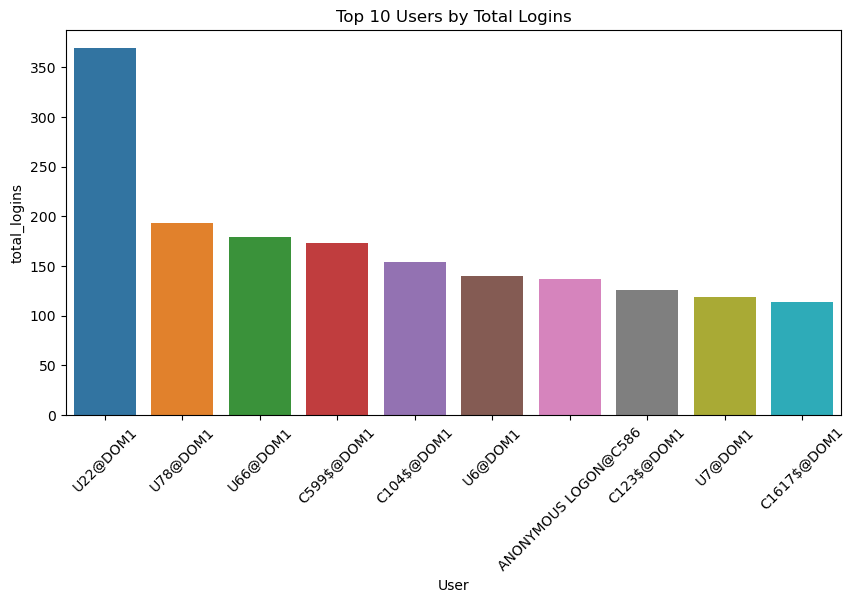

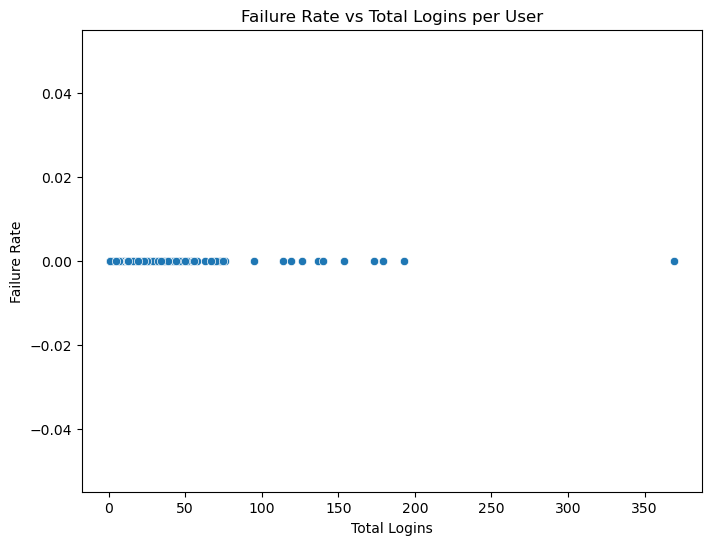

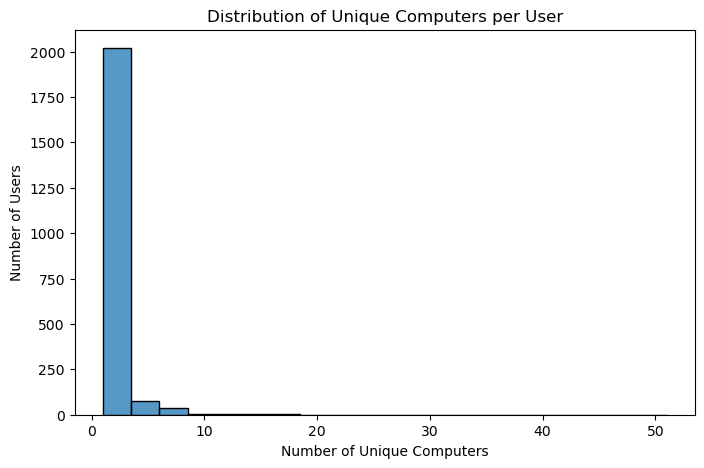

In [6]:
user_stats = df.groupby('User').agg(
    total_logins=('RecordID','count'),
    failed_logins=('Success', lambda x: (x=='Failure').sum()),
    unique_computers=('TargetComputer','nunique')
).reset_index()
user_stats['fail_rate'] = user_stats['failed_logins'] / user_stats['total_logins']

# --- Bar chart of top 10 users by total logins ---
top10_users = user_stats.sort_values('total_logins', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='User', y='total_logins', data=top10_users)
plt.xticks(rotation=45)
plt.title("Top 10 Users by Total Logins")
plt.show()

# --- Scatter plot: fail_rate vs total_logins ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='total_logins', y='fail_rate', data=user_stats)
plt.xlabel("Total Logins")
plt.ylabel("Failure Rate")
plt.title("Failure Rate vs Total Logins per User")
plt.show()

# --- Histogram of unique computers per user ---
plt.figure(figsize=(8,5))
sns.histplot(user_stats['unique_computers'], bins=20, kde=False)
plt.xlabel("Number of Unique Computers")
plt.ylabel("Number of Users")
plt.title("Distribution of Unique Computers per User")
plt.show()

Our first chart shows the histogram of the users with the most logins. We see that a few of these have $ in their names, suggesting admin or a machine user. We also see one "ANONYMOUS" account.

Next, the failure rate vs total number of logins. As the failure rate was so low, this looks relatively flat. So, we can use it to see the usual user only logs in to ~1-50 computers, with some outliers having much more.

Our third graph confirms this intuition. Of the 2142 users in the first 10k rows, about 2000 of them only connect to 1-2 computers!

### Lets use some popular stateless models to see if they can detect the same anomalies from the data:

Users flagged by multiple models:
             User  total_logins  failed_logins  unique_computers  fail_rate  \
2100      U6@DOM1           140              0                18        0.0   
125   C1114$@DOM1            76              0                 8        0.0   
2118      U7@DOM1           119              0                 8        0.0   
634   C1766$@DOM1            73              0                 9        0.0   
621   C1734$@DOM1            28              0                 8        0.0   
2114     U78@DOM1           193              0                11        0.0   
1737   C832$@DOM1            39              0                 2        0.0   
1282  C3554$@DOM1            38              0                 2        0.0   
1122  C2796$@DOM1            28              0                 8        0.0   
1992    U175@DOM1            23              0                12        0.0   

      iso_anomaly  lof_anomaly  svm_anomaly  num_models_flagged  
2100         True         True

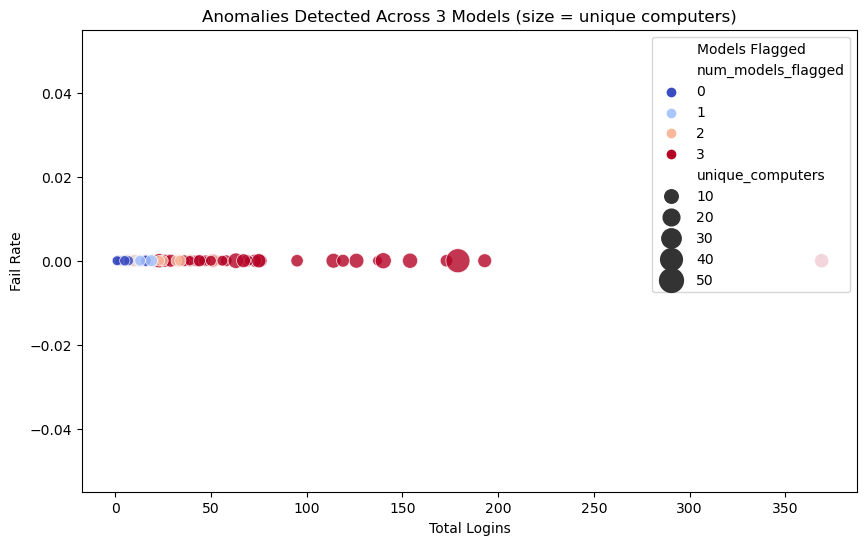


Percentage of $ accounts flagged by all 3 models: 1.08%
Users flagged by 1 model(s): 77
Users flagged by 2 model(s): 42
Users flagged by 3 model(s): 49


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# --- Prepare features ---
features = ['total_logins', 'failed_logins', 'unique_computers', 'fail_rate']
X = user_stats[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Fit models ---
# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
user_stats['iso_anomaly'] = iso_forest.fit_predict(X_scaled) == -1

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
user_stats['lof_anomaly'] = lof.fit_predict(X_scaled) == -1

# One-Class SVM
oc_svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
user_stats['svm_anomaly'] = oc_svm.fit_predict(X_scaled) == -1

# --- Count agreement ---
user_stats['num_models_flagged'] = user_stats[['iso_anomaly','lof_anomaly','svm_anomaly']].sum(axis=1)

print("Users flagged by multiple models:")
print(user_stats.sort_values('num_models_flagged', ascending=False).head(10))

# --- Visualize model agreement ---
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='total_logins', 
    y='fail_rate', 
    hue='num_models_flagged', 
    palette='coolwarm', 
    size='unique_computers', 
    sizes=(50,300),
    alpha=0.8,
    data=user_stats
)
plt.xlabel("Total Logins")
plt.ylabel("Fail Rate")
plt.title("Anomalies Detected Across 3 Models (size = unique computers)")
plt.legend(title="Models Flagged")
plt.show()

# --- % of anomalies for $ accounts ---
dollar_accounts = user_stats[user_stats['User'].str.contains(r'\$', regex=True)]
percent_anomalous_dollar = (dollar_accounts['num_models_flagged'] == 3).mean() * 100

print(f"\nPercentage of $ accounts flagged by all 3 models: {percent_anomalous_dollar:.2f}%")

# --- Total flagged counts per number of models ---
for n in range(1, 4):
    count = (user_stats['num_models_flagged'] == n).sum()
    print(f"Users flagged by {n} model(s): {count}")


So, we have a bunch of flags! We set our sensitivity quite high, at 5%, so this is not surprising. We see a couple users logged in a bunch of times, to a bunch of unique computers. In fact, it seems like most of the accounts with over a certain number of total logins gets flagged by all 3 models!

We have a graph of the anomalies detected across all 3 models. We can see the system flags accounts that have a lot of login attempts as well as a large number of unique computers (how large the dot is).

We can see that 77 users are flagged by at least 1 model, 42 are flagged by 2 models, and 49 are flagged by 3. Only 1.08% of the flagged users are admin accounts. This suggests that while our models are sensitive, they are effectively picking up on anomalous data.

### Lets do some EDA on our model results:

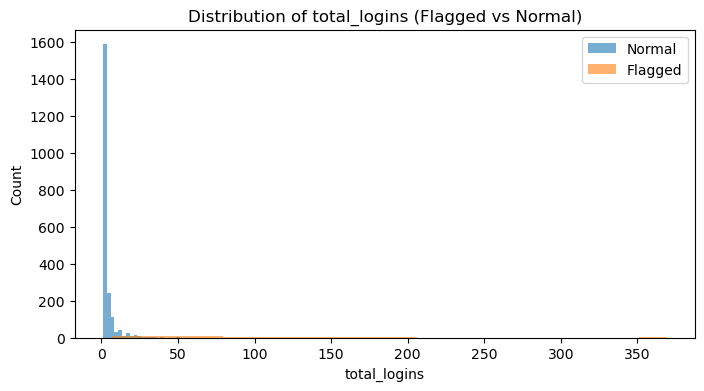

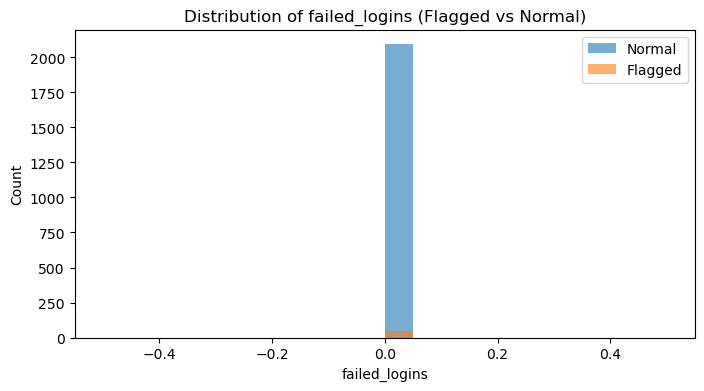

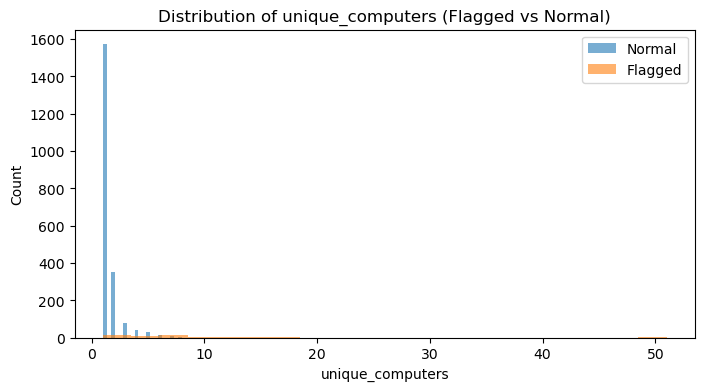

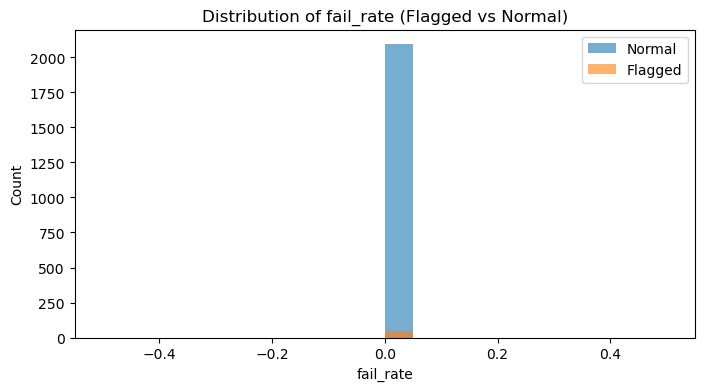

/Users/williammumper/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


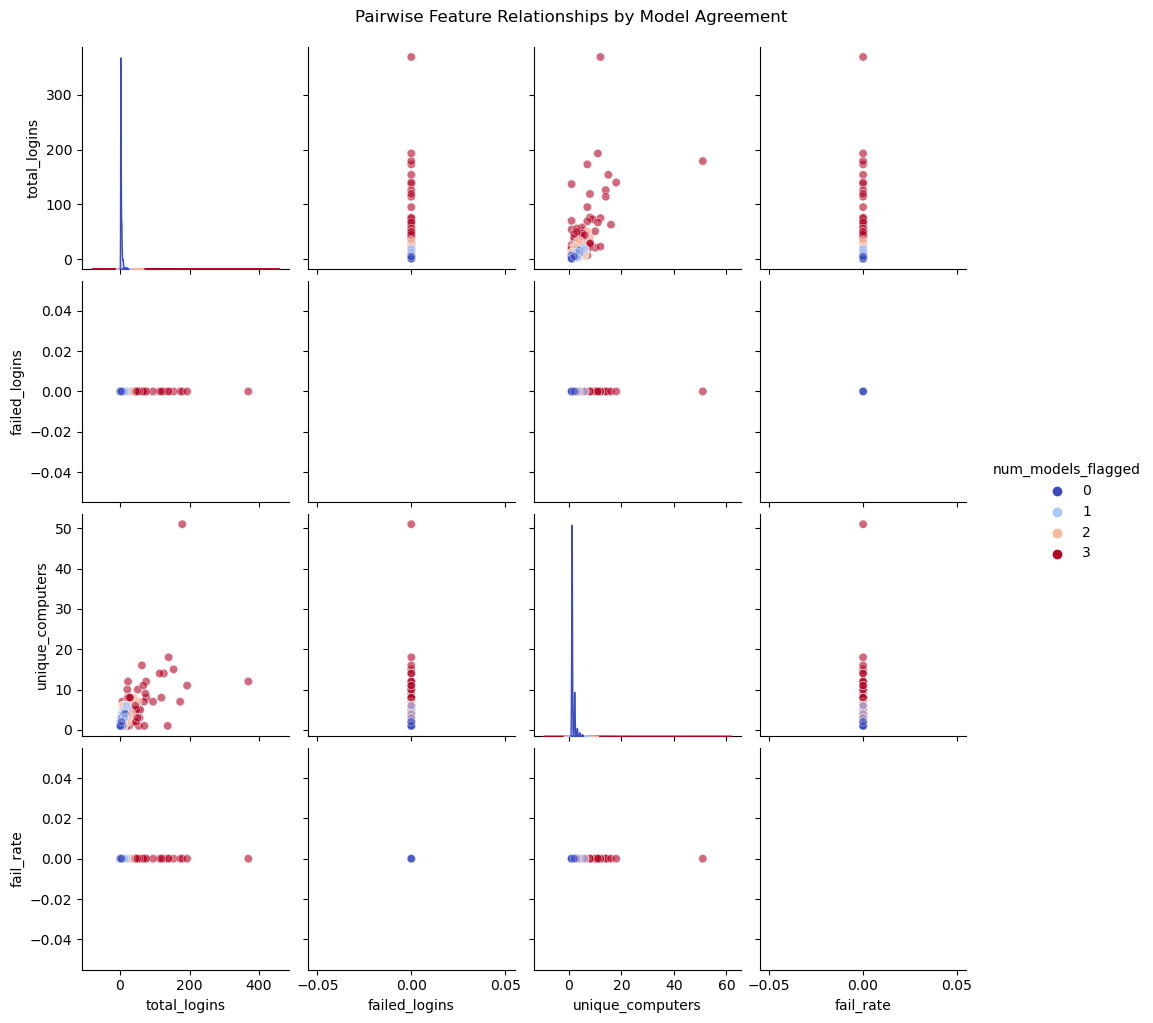

In [14]:
flagged = user_stats['num_models_flagged'] == 3

for col in ['total_logins', 'failed_logins', 'unique_computers', 'fail_rate']:
    plt.figure(figsize=(8,4))
    plt.hist(user_stats.loc[~flagged, col], bins=20, alpha=0.6, label='Normal')
    plt.hist(user_stats.loc[flagged, col], bins=20, alpha=0.6, label='Flagged')
    plt.title(f'Distribution of {col} (Flagged vs Normal)')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()
    
sns.pairplot(user_stats, vars=['total_logins','failed_logins','unique_computers','fail_rate'],
             hue='num_models_flagged', palette='coolwarm', plot_kws={'alpha':0.6})
plt.suptitle("Pairwise Feature Relationships by Model Agreement", y=1.02)
plt.show()


These graphs give a good idea of what our models are flagging. Specifically, the total_logins vs unique_computers graph shows our real anomalous data. When a user connects to a lot of computers, its flagged. While this would certainly catch obvious red team behavior it is not robust enough to detect slow and low attacks that mimic normal behavior. We would expect maybe 10-30% detection rate with this. This shows the limitations with a small slice of data and also using basic stateless models.

### END EDA.